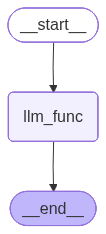

In [4]:
def add(a:int,b:int)->int:
    """ Docstring for add
    
    :param a: Description
    :type a: int
    :param b: Description
    :type b: int
    :return: Description
    :rtype: int"""

    return a+b

from langgraph.graph import StateGraph,START,END
from langchain_core.messages import HumanMessage,AIMessage,AnyMessage
from langchain_openai import ChatOpenAI
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph.message import add_messages
from IPython.display import Image,display

llm = ChatOpenAI(model="gpt-4o-mini")

llm_tool = llm.bind_tools([add])

class State(TypedDict):
    messages : Annotated[list[AnyMessage],add_messages]

def llm_func(state:State):
    return {"messages":[llm_tool.invoke(state['messages'])]}

inital_message = [AIMessage(content="Hi How can I help you",name="llmmodel")]
inital_message.append(HumanMessage(content="I want to learn programming",name="Harika"))

aimessage = AIMessage(content="Which PL you want to learn",name="llmmodel")

add_messages(inital_message,aimessage)

builder = StateGraph(State)

builder.add_node('llm_func',llm_func)
builder.add_edge(START,'llm_func')
builder.add_edge('llm_func',END)


graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))


In [5]:
messages = graph.invoke({"messages":"what is 2+2"})
for message in messages['messages']:
    message.pretty_print()

================================ Human Message =================================

what is 2+2
================================== Ai Message ==================================
Tool Calls:
  add (call_lQyl4Mm1wsi8LBUHbEKOya21)
 Call ID: call_lQyl4Mm1wsi8LBUHbEKOya21
  Args:
    a: 2
    b: 2


In [7]:
tools = [add]

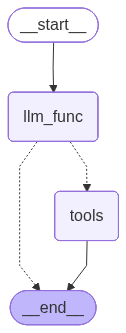

In [8]:
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

builder=StateGraph(State)

builder.add_node('llm_func',llm_func)
builder.add_edge(START,'llm_func')
builder.add_node("tools",ToolNode(tools))
builder.add_conditional_edges('llm_func',
                              # If the latest message (result) from assistant is a tool call->tool_condition routes to tools
                              # If the latest message (result) from assistant is not a tool call->tool_condition routes to END
                              tools_condition)

graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [9]:
messages = graph.invoke({"messages":"what is 2+2"})
for message in messages['messages']:
    message.pretty_print()

================================ Human Message =================================

what is 2+2
================================== Ai Message ==================================
Tool Calls:
  add (call_EsBPRdievhYbTzb1aYNq0w2B)
 Call ID: call_EsBPRdievhYbTzb1aYNq0w2B
  Args:
    a: 2
    b: 2
================================= Tool Message =================================
Name: add

4
